In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-


# Deep Neural Networks

## Session 14b
## Working with PyTorch
- multi-class output
- Ionosphere
- Regularization
- BatchNorm
- Dropout

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix

In [3]:
# Some basic parameters
inpDir = Path('../../input')
outDir = Path('../output')
modelDir = Path('../models')
subDir = 'text_gen'

RANDOM_STATE = 24
torch.manual_seed(RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 75 # number of epochs

BATCH_SIZE = 64
ALPHA = 0.001 # learning rate
WEIGHT_DECAY = 1e-4 # Weight decay

NUM_GENERATE = 1000
TEMPERATURE = 0.8
BUFFER_SIZE = 10000
SEQ_LENGTH = 100
EMBEDING_DIM = 256
RNN_UNITS = 1024
PATIENCE = 10
MIN_DELTA = 1e-4
LR_PATIENCE =5
LR_FACTOR = 0.1
TEST_SIZE = 0.2

 
# parameters for Matplotlib
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }


CMAP = plt.cm.brg

plt.rcParams.update(params)

In [4]:
# Check Model Directory
( modelDir / subDir ).mkdir(parents=True, exist_ok=True)    

In [5]:
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed = RANDOM_STATE)
    device = torch.device('cuda')

else:
    device = torch.device('cpu')
    
print(device)

cpu


## Load Data

### Data Set Information:

This radar data was collected by a system in Goose Bay, Labrador. This system consists of a phased array of 16 high-frequency antennas with a total transmitted power on the order of 6.4 kilowatts. See the paper for more details. The targets were free electrons in the ionosphere. "Good" radar returns are those showing evidence of some type of structure in the ionosphere. "Bad" returns are those that do not; their signals pass through the ionosphere.

Received signals were processed using an autocorrelation function whose arguments are the time of a pulse and the pulse number. There were 17 pulse numbers for the Goose Bay system. Instances in this database are described by 2 attributes per pulse number, corresponding to the complex values returned by the function resulting from the complex electromagnetic signal.

Attribute Information:

-- All 34 are continuous
-- The 35th attribute is either "good" or "bad" according to the definition summarized above. This is a binary classification task.

We will model this as two class.

In [6]:
# data_df = pd.read_csv('D:/Deep_Learning/SharedData/shakespeare.txt')
# data_df.shape

file_path = 'D:/Deep_Learning/SharedData/shakespeare.txt'

text = pd.read_csv(
    file_path, 
    sep='\0',   # Forces pandas to treat the entire line as one string
    header=None, 
    names=['text'], 
    encoding='utf-8'
)

print(text.shape)
print(text.head())

(32777, 1)
                                            text
0                                 First Citizen:
1  Before we proceed any further, hear me speak.
2                                           All:
3                                  Speak, speak.
4                                 First Citizen:


In [7]:
vocab = sorted(set(text))
vocab_size = len(vocab)
vocab_size

1

In [8]:
char2idx = {v:i for i, v in enumerate(vocab)}
idx2char = np.array(vocab)
text_as_int = np.array([char2idx[c] for c in text])
text_as_int.shape

(1,)

# Datasets

In [9]:
class ShakespearDataset(Dataset):
    
    def __init__ (self, text_as_int, seq_length):
        
        super(ShakespearDataset, self). __init__()
        self.sequences = []
        self.seq_length = seq_length
        # self.text_as_int = text_as_int
        
        for i in range (0, len(text_as_int)-seq_length, seq_length):
            self.sequences.append(text_as_int[i:i+seq_length+1])
        self.sequences = np.array(self.sequences)
        
    def __len__ (self):
        return len(self.sequences)
    
    def __getitem__(self, index):
        seq = self.sequences[index]
        
        input_seq = torch.tensor(seq[:-1], dtype =torch.long)
        target_seq = torch.tensor(seq[1:], dtype =torch.long)
        
        return input_seq, target_seq

In [10]:
dataset = ShakespearDataset(text_as_int, seq_length= SEQ_LENGTH)
len(dataset)

0

In [11]:
train_size = int((0.8* len(dataset)) // BATCH_SIZE*BATCH_SIZE)
test_size = len(dataset)-train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size],
    generator = torch.Generator().manual_seed(RANDOM_STATE)
)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
len(train_loader), len(test_loader)

(0, 0)

In [13]:
inputs, targets = next(iter(train_loader))
first_input = inputs[0]
first_target = targets[0]
first_input, first_target

StopIteration: 

In [ ]:
inp_chars = ''.join([idx2char[idx]
                     for idx in first_input.numpy()])

target_chars = ''.join([idx2char[idx]
                        for idx in first_target.numpy()])

inp_chars, target_chars

NameError: name 'first_input' is not defined

In [ ]:
class CharRNN(nn.Module):
    
    def __init__(self,
                 vocab_size,
                 )

# Train 

In [14]:
def train_model(model, train_loader,
                loss_fn = loss_fn,
                optimizer = optimizer,
                scheduler = scheduler,
                device = device):
    model.train()
    
    total_loss = 0
    
    for train_X, train_y in train_loader:
        train_X, train_y = train_X.to(device), train_y.to(device)
        hidden = model.init_hidden(train_X.size(0), device)  # Hidden state (a_t)
        optimizer.zero_grad()
        logits, hidden = model(train_X, hidden)  # forward pass
        batch_loss = loss_fn(logits.reshape(-1, vocab_size), train_y.reshape(-1))
        
        batch_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)   # gradient clipping
        optimizer.step()
        total_loss += batch_loss.item()
        
        hidden =hidden.detach()
        
    avg_loss = total_loss / len(train_loader)
    return avg_loss
        
    

NameError: name 'loss_fn' is not defined

In [ ]:

def evaluate(model, test_loader, loss_fn=loss_fn, device=device):
    """Evaluates the model performance on a test dataset."""
    
    model.eval()  # Set model to evaluation mode
    total_loss = 0

    with torch.inference_mode():  # Disable gradient tracking
        # enumerate gives you the batch_idx needed for the running average
        for test_X, test_y in test_loader:
            test_X, test_y = test_X.to(device), test_y.to(device)
            hidden = model.init_hidden(test_X.size(0), device)
            logits, hidden = model(test_X, hidden)  # forward pass
            batch_loss = loss_fn(logits.reshape(-1, vocab_size), test_y.reshape(-1))
            total_loss += batch_loss.item()
            
    avg_loss = total_loss / len(test_loader)
    return avg_loss


In [ ]:
history = {
    'epoch': [],
    'train_loss': [],
    'test_loss': [],
    'train_rmse': [],
    'test_rmse': []
}

best_test_loss = float('inf')
best_model_state = None

for epoch in range(EPOCHS):
    # Train
    train_loss = train_model(model, train_loader)
    train_rmse = np.sqrt(train_loss)

    # Test
    test_loss = evaluate(model, test_loader)
    test_rmse = np.sqrt(test_loss)

    scheduler.step(test_loss)

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_rmse'].append(train_rmse)
    history['test_rmse'].append(test_rmse)


if test_loss < best_test_loss:
    best_test_loss = test_loss
    best_model_state = model.state_dict().copy()

if epoch % 10 == 0:
    
    print (f'Epoch: {epoch:5d}/{EPOCHS:50} |'
            f'LR:{optimizer.param_groups[0]['lr']:0.6f} | '
            f'Train Loss: {train_loss:.4f} | '
            f'Test Loss:{test_loss:.4f}')


print (f'Best loss: {best_test_loss}')

if best_model_state is not None:
    model.load_state_dict(best_model_state)

In [ ]:
@torch.inference_mode()
def generate_text(model, start_string, 
                  num_generate=NUM_GENERATE, 
                  temperature=TEMPERATURE, 
                  device=device):
    
    model.eval()
    
    input_indices = [char2idx.get(ch, 0) for ch in start_string]
    print(f'Start string: {start_string} | Indices: {input_indices}')
    input_tensor = torch.tensor([input_indices], dtype=torch.long, device=device)
    hidden = model.init_hidden(1, device)
    generated_chars = []

    for _ in range(num_generate):
        logits, hidden = model(input_tensor, hidden)
        logits = logits[0, -1, :] / temperature
        probs = torch.softmax(logits, dim=-1)
        
        next_char_idx = torch.multinomial(probs, num_samples=1).item()
        generated_chars.append(idx2char[next_char_idx])
        
        input_tensor = torch.tensor([[next_char_idx]], dtype=torch.long, device=device)
        hidden = hidden.detach()

    return start_string + "".join(generated_chars)


In [ ]:
#  Split the data in training and test sets to measure performance of the model.
train_df, test_df = train_test_split(data_df,
                                     train_size=TRAIN_SIZE,
                                     stratify=data_df[data_df.columns[-1]],
                                     random_state=RANDOM_STATE )

train_df.shape, test_df.shape

((288, 35), (63, 35))

## All about CUDA

In [ ]:
print ('Is CUDA available: ', torch.cuda.is_available())

print ('CUDA version: ', torch.version.cuda )

print ('Current Device ID: ', torch.cuda.current_device())

print ('Name of the CUDA device: ', torch.cuda.get_device_name(torch.cuda.current_device()))

Is CUDA available:  True
CUDA version:  13.0
Current Device ID:  0
Name of the CUDA device:  NVIDIA GeForce RTX 3060 Laptop GPU


In [ ]:
# Get cpu or gpu device for training.

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f"Using {device} device")

Using cuda device


In [ ]:
class DataTransformer:
    """Wrapper for StandardScaler and LabelEncoder"""
    def __init__(self):
        self.scaler = StandardScaler()
        self.encoder = LabelEncoder()
        self.is_fitted = False
    
    def fit(self, X, y):
        self.scaler.fit(X)
        self.encoder.fit(y)
        self.is_fitted = True
        return self
    
    def transform(self, X, y):
        if not self.is_fitted:
            raise ValueError("Transformer must be fitted before transform")
        return self.scaler.transform(X), self.encoder.transform(y)
    
    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X, y)

In [ ]:
'''
In this code, we define a custom dataset called FifaDS that takes a DataFrame as input. 

'''

class IonoDS(Dataset):
    
    def __init__(self, 
                 dataframe: pd.DataFrame, 
                 device : str = device, 
                 is_train = True,
                 label_col = None,
                 transformer = None
                ):
        
        super(IonoDS, self).__init__()

        self.df = dataframe
        self.device = device
        self.is_train = is_train
        self.transformer = transformer
        self.label_col = label_col
        

        y = self.df[label_col].to_numpy()
        X = self.df.drop(label_col, axis = 1)

        if self.is_train:
            self.transformer = DataTransformer()
            self.features, self.labels = self.transformer.fit_transform(X, y)
        else:
            if self.transformer is None:
                raise ValueError("Test set requires pre-fitted transformer")
            self.features, self.labels = self.transformer.transform(X, y)
        
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, index):
        # Extract features and label from the dataframe row
        features = self.features[index]
        label = self.labels[index]
        
        # Convert to PyTorch tensors
        features = torch.tensor(features, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.int64)
        
        return features, label

In [ ]:
class Model(nn.Module):
    
    def __init__(self, input_dim):
        
        super(Model, self).__init__()

        dor1 = 0.05
        dor2 = 0.15
        dor3 = 0.25
        
        self.layer1 = nn.Linear(input_dim,26)
        self.bn1 = nn.BatchNorm1d(26)  # implementing Batch Normalization
        self.do1 = nn.Dropout(dor1)  # implementing Drop out
        self.act1 = nn.ReLU()

        self.layer2 = nn.Linear(26, 18)
        self.bn2 = nn.BatchNorm1d(18)  # implementing Batch Normalization
        self.do2 = nn.Dropout(dor2)  # implementing Drop out
        self.act2 = nn.ReLU()
 
        self.layer3 = nn.Linear(18, 10)
        self.bn3 = nn.BatchNorm1d(10)  # implementing Batch Normalization
        self.do3 = nn.Dropout(dor3)  # implementing Drop out
        self.act3 = nn.ReLU()

        self.layer4 = nn.Linear(10, 2)
        
         
    def forward(self, x):

        # Activation Functions by layer
        
        x = self.do1(self.act1 ( self.bn1 ( self.layer1 ( x ) ) )) 
        x = self.do2(self.act2 ( self.bn2 ( self.layer2 ( x ) ) )) 
        x = self.do3(self.act3 ( self.bn3 ( self.layer3 ( x ) ) )) 
        
        output = self.layer4(x)
        
        return output

input_dim = 34
model = Model(input_dim).to(device) # Create model on GPU

print (model)

Model(
  (layer1): Linear(in_features=34, out_features=26, bias=True)
  (bn1): BatchNorm1d(26, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (do1): Dropout(p=0.05, inplace=False)
  (act1): ReLU()
  (layer2): Linear(in_features=26, out_features=18, bias=True)
  (bn2): BatchNorm1d(18, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (do2): Dropout(p=0.15, inplace=False)
  (act2): ReLU()
  (layer3): Linear(in_features=18, out_features=10, bias=True)
  (bn3): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (do3): Dropout(p=0.25, inplace=False)
  (act3): ReLU()
  (layer4): Linear(in_features=10, out_features=2, bias=True)
)


In [ ]:
label_col = 34
train_ds = IonoDS(train_df, is_train = True, label_col = label_col)
test_ds = IonoDS(test_df, is_train = False, label_col = label_col, transformer=train_ds.transformer)

In [ ]:
# Define data loaders for the training and testing datasets
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# Define the loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # cross entropy loss

train_losses, test_losses = [], []
train_accs, test_accs = [], []
n_epoch = []

optimizer = torch.optim.Adam(model.parameters(),
                             lr=ALPHA, 
                             weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                     mode='min', 
                                                     factor=LR_FACTOR, 
                                                     patience=LR_PATIENCE,
                                                     min_lr=1e-5)
# Min Loss
minLoss = float('inf')
counter = 0

# Path to save the model
savePath = modelDir / subDir / 'iono.pth'

# Train the model for multiple epochs
for epoch in range(EPOCHS):
    
    # Training loop
    train_loss = 0.0
    train_acc = 0.0

    model.train()  # Set the model to training mode
    
    for data in train_loader:
        
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move data to GPU
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        
        preds = torch.argmax(outputs, dim = 1)
        
        batch_loss = loss_fn(outputs.squeeze(), labels)
        batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
        
        batch_loss.backward()
        
        optimizer.step()
        
        train_loss += batch_loss.item() * inputs.size(0)
        train_acc += batch_acc * inputs.size(0)
    
    train_loss /= len(train_ds)
    train_acc /= len(train_ds)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Testing loop
    test_loss = 0.0
    test_acc = 0.0

    model.eval()  # Set the model to evaluation mode
    
    with torch.inference_mode():
        
        for data in test_loader:
            
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device) # Move data to GPU
            
            outputs = model(inputs)
            
            preds = torch.argmax(outputs, dim = 1)
            
            batch_loss = loss_fn(outputs, labels)

            batch_acc = accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())
            
            test_loss += batch_loss.item() * inputs.size(0)
            test_acc += batch_acc* inputs.size(0)
        
        test_loss /= len(test_ds)
        test_acc /= len(test_ds)
    
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
    n_epoch.append(epoch)

    # Step the scheduler
    scheduler.step(test_loss)

    ##### Add Early stopping/ Saving Model #####
    if test_loss < minLoss:
        minLoss = test_loss
        counter = 0
        # Saving Model
        torch.save({ 'epoch': epoch + 1,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'loss': test_loss,}, savePath )

    else:
        counter +=1
    if counter > PATIENCE:
        break
    #-----------------------------
    if epoch%10 == 0:
        print(f'At epoch {epoch:3d} | Loss: {train_loss:.4f} / {test_loss:.4f} | Acc:{train_acc:.4f} / {test_acc:.4f}| LR: {scheduler.get_last_lr()[0]:.5f} |Counter: {counter}')

At epoch   0 | Loss: 0.6783 / 0.6121 | Acc:0.6215 / 0.7460| LR: 0.00100 |Counter: 0
At epoch  10 | Loss: 0.3129 / 0.2473 | Acc:0.8819 / 0.8889| LR: 0.00100 |Counter: 0
At epoch  20 | Loss: 0.1835 / 0.1485 | Acc:0.9479 / 0.9365| LR: 0.00100 |Counter: 0
At epoch  30 | Loss: 0.2288 / 0.1215 | Acc:0.9097 / 0.9524| LR: 0.00100 |Counter: 1
At epoch  40 | Loss: 0.1620 / 0.0989 | Acc:0.9479 / 0.9524| LR: 0.00010 |Counter: 11
At epoch  50 | Loss: 0.1330 / 0.1062 | Acc:0.9444 / 0.9524| LR: 0.00001 |Counter: 6
At epoch  60 | Loss: 0.1761 / 0.1058 | Acc:0.9479 / 0.9524| LR: 0.00001 |Counter: 16


In [ ]:
loss_df = pd.DataFrame({'epoch': n_epoch,
                        'loss' : train_losses,
                        'test_loss' : test_losses,
                        'acc' : train_accs,
                        'test_acc': test_accs})

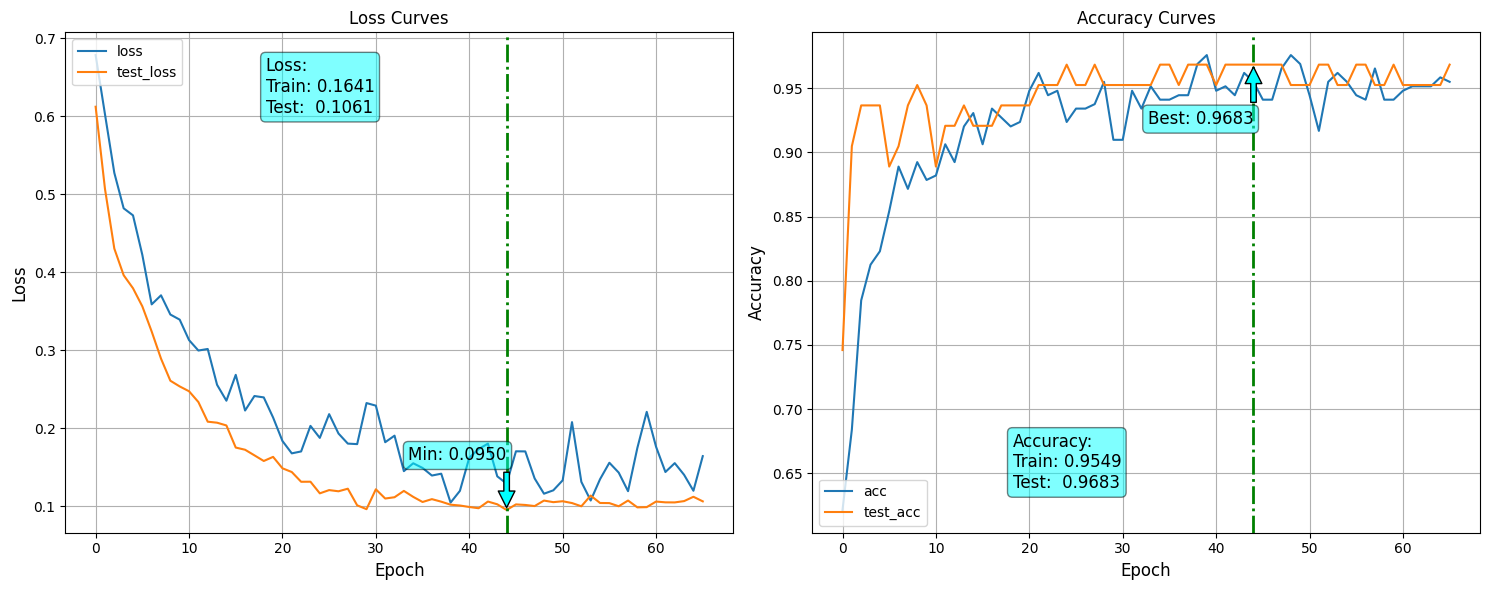

In [ ]:
fn_plot_torch_hist(loss_df)

## Training Accuracy

In [ ]:
y_train = []
y_pred = []

model.eval()  # Set the model to evaluation mode
    
with torch.inference_mode():

    for data in train_loader:
        
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move data to GPU
        
        outputs = model(inputs)
        
        preds = torch.argmax(outputs, dim = 1)

        y_train.extend(labels.cpu().numpy())

        y_pred.extend(preds.cpu().numpy())

print (f'Train Accuracy:{accuracy_score(y_train, y_pred ):.5f}\n')

print(classification_report(y_train,y_pred))

Train Accuracy:0.97917

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       103
           1       0.97      0.99      0.98       185

    accuracy                           0.98       288
   macro avg       0.98      0.97      0.98       288
weighted avg       0.98      0.98      0.98       288



In [ ]:
train_ds.transformer.encoder.classes_

array(['b', 'g'], dtype=object)

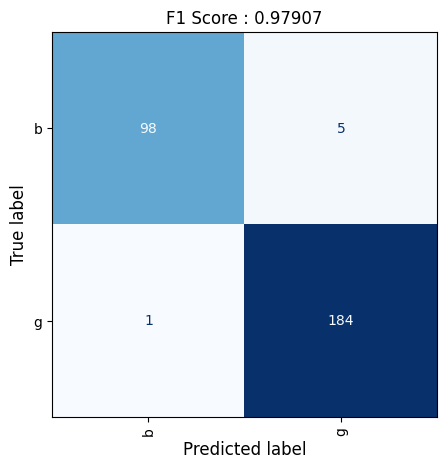

In [ ]:
class_names = {k : v for k, v in enumerate(train_ds.transformer.encoder.classes_)}
fn_plot_confusion_matrix(y_train,y_pred, class_names)

## Testing Accuracy

In [ ]:
y_test = []
y_pred = []

model.eval()  # Set the model to evaluation mode
    
with torch.inference_mode():
    
    for data in test_loader:
        
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device) # Move data to GPU
        
        outputs = model(inputs)
        
        preds = torch.argmax(outputs, dim = 1)

        y_test.extend(labels.cpu().numpy())

        y_pred.extend(preds.cpu().numpy())

print (f'Test Accuracy:{accuracy_score(y_test, y_pred ):.5f}\n')

print(classification_report(y_test, y_pred ))

Test Accuracy:0.96825

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       0.97      0.97      0.97        40

    accuracy                           0.97        63
   macro avg       0.97      0.97      0.97        63
weighted avg       0.97      0.97      0.97        63



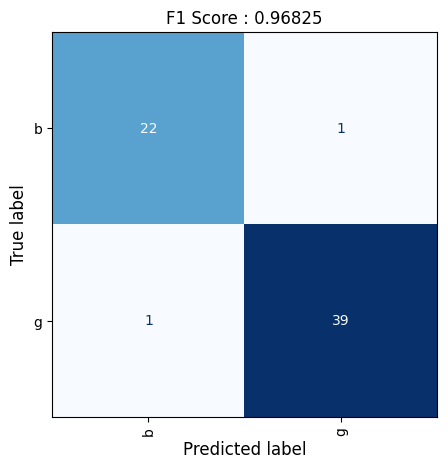

In [ ]:
fn_plot_confusion_matrix(y_test, y_pred, class_names)

In [ ]:
model1 = Model(input_dim).to(device)

In [ ]:
model_dict = torch.load(savePath)
model_dict.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'])

In [ ]:
model_dict['model_state_dict'].keys()

odict_keys(['layer1.weight', 'layer1.bias', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'bn1.num_batches_tracked', 'layer2.weight', 'layer2.bias', 'bn2.weight', 'bn2.bias', 'bn2.running_mean', 'bn2.running_var', 'bn2.num_batches_tracked', 'layer3.weight', 'layer3.bias', 'bn3.weight', 'bn3.bias', 'bn3.running_mean', 'bn3.running_var', 'bn3.num_batches_tracked', 'layer4.weight', 'layer4.bias'])

In [ ]:

model1.load_state_dict(model_dict['model_state_dict'])
model1.eval()

Model(
  (layer1): Linear(in_features=34, out_features=26, bias=True)
  (bn1): BatchNorm1d(26, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (do1): Dropout(p=0.05, inplace=False)
  (act1): ReLU()
  (layer2): Linear(in_features=26, out_features=18, bias=True)
  (bn2): BatchNorm1d(18, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (do2): Dropout(p=0.15, inplace=False)
  (act2): ReLU()
  (layer3): Linear(in_features=18, out_features=10, bias=True)
  (bn3): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (do3): Dropout(p=0.25, inplace=False)
  (act3): ReLU()
  (layer4): Linear(in_features=10, out_features=2, bias=True)
)

In [ ]:
y_test = []
y_pred = []

for data in test_loader:
    
    inputs, labels = data
    inputs, labels = inputs.to(device), labels.to(device) # Move data to GPU
    
    outputs = model1(inputs)
    
    preds = torch.argmax(outputs, dim = 1)

    y_test.extend(labels.cpu().numpy())

    y_pred.extend(preds.cpu().numpy())

print (f'Test Accuracy:{accuracy_score(y_test, y_pred ):.5f}\n')

print(classification_report(y_test, y_pred ))

Test Accuracy:0.96825

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       0.97      0.97      0.97        40

    accuracy                           0.97        63
   macro avg       0.97      0.97      0.97        63
weighted avg       0.97      0.97      0.97        63

